## How well do jobs and skills pay for Data Analysts?
Methodology
1. Evaluate median salary for top 6 data jobs
3. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Data - only data for 2023
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

# Loading Data - 2023, 2024, 2025 and first half of 2026:
df = pd.read_csv(r"C:\Users\Nikola S\Desktop\Luke B\job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Salary Distribution by Job Title
Filter our data to only include salary values from the United States.

In [5]:
df_US = df[df["job_country"] == "United States"].dropna(subset="salary_year_avg")
df_US.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77752 entries, 59 to 1926511
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        77752 non-null  object        
 1   job_title              77752 non-null  object        
 2   job_location           77483 non-null  object        
 3   job_via                77752 non-null  object        
 4   job_schedule_type      77456 non-null  object        
 5   job_work_from_home     77752 non-null  bool          
 6   search_location        77752 non-null  object        
 7   job_posted_date        77752 non-null  datetime64[ns]
 8   job_no_degree_mention  77752 non-null  bool          
 9   job_health_insurance   77752 non-null  bool          
 10  job_country            77752 non-null  object        
 11  salary_rate            77752 non-null  object        
 12  salary_year_avg        77752 non-null  float64       
 13  sal

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [39]:
job_titles = df[df["job_title_short"].str.contains("Data", case=False, na=False)]
job_titles = job_titles["job_title_short"].value_counts().index[:7].to_list()

job_titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst']

In [40]:
#job_titles = df["job_title_short"].value_counts().index[:6].to_list()
#job_titles

In [41]:
df_US_top7 = df_US[df["job_title_short"].isin(job_titles)]
df_US_top7.head(5)

C:\Users\Nikola S\AppData\Local\Temp\ipykernel_50048\2781051525.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_US_top7 = df_US[df["job_title_short"].isin(job_titles)]


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
59,Data Scientist,Data Scientist,"Calabasas, CA",via Recruit.net,Full-time,False,"California, United States",2023-01-01 00:02:56,False,True,United States,year,110000.0,NaN,PlanetArt,"[python, sql, tableau, excel]","{'analyst_tools': ['tableau', 'excel'], 'progr..."
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,"[sql, python, numpy, pandas, seaborn, matplotl...","{'analyst_tools': ['excel', 'alteryx', 'tablea..."
240,Data Scientist,Lead Data Scientist (Hybrid),"Burnsville, MN",via Recruit.net,Full-time,False,"Illinois, United States",2023-01-01 00:21:09,False,False,United States,year,120531.0,NaN,Apple Valley,"[java, sql, sql server, spring]","{'databases': ['sql server'], 'libraries': ['s..."
253,Data Engineer,Data Engineer - Revenue Platforms,"Boston, NY",via Recruit.net,Full-time,False,"Texas, United States",2023-01-01 00:24:39,False,True,United States,year,300000.0,NaN,Datadog,"[scala, python, spark]","{'libraries': ['spark'], 'programming': ['scal..."
530,Data Scientist,Data Science Manager,"Carnegie, PA",via Indeed,Full-time,False,Georgia,2023-01-01 04:18:15,False,True,United States,year,133500.0,NaN,VISIMO,"[python, numpy, pandas, scikit-learn, nltk, ma...","{'libraries': ['numpy', 'pandas', 'scikit-lear..."


In [42]:
job_order = df_US_top7.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

## Plot Salary Distributions
Plot the top 6 job titles salary distributions using a box plot.

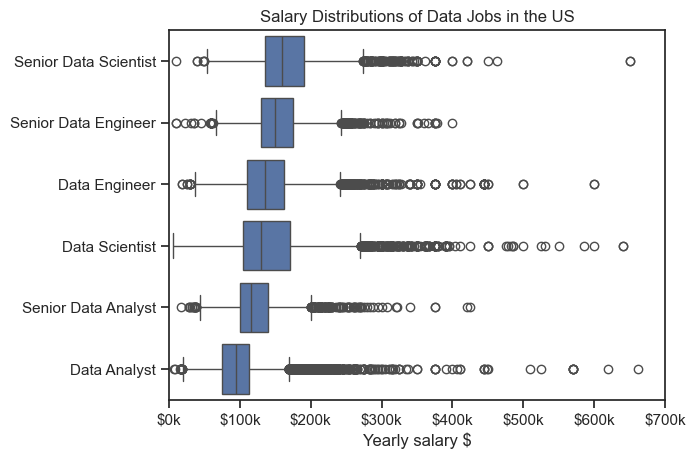

In [43]:
sns.boxplot(data = df_US_top7, x="salary_year_avg", y="job_title_short", order = job_order)
plt.xlabel("Yearly salary $")
plt.ylabel("")
plt.title("Salary Distributions of Data Jobs in the US")
plt.xlim(0,700000) 
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame df_DA_US. Drop NaN values from the 'salary_year_avg' column. Then it uses the explode method on the job_skills column to create a new row in the DataFrame for each skill associated with a job.

In [25]:
df_DA_US = df[(df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst")].copy()
df_DA_US = df_DA_US.dropna(subset="salary_year_avg")
df_DA_US = df_DA_US.explode("job_skills")

In [26]:
df_DA_US.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,sql,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,python,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,numpy,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,pandas,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."
218,Data Analyst,Data Analytics Professional,"Atlanta, GA",via CareerBuilder,Full-time,False,Georgia,2023-01-01 00:17:58,False,False,United States,year,55000.0,NaN,Cogent Infotech.,seaborn,"{'analyst_tools': ['excel', 'alteryx', 'tablea..."


## Determine The Highest Paid Skills and Most Demanded Skills

In [27]:
df_DA_top_pay = df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="median", ascending=False)
df_top_pay = df_DA_top_pay.head(10)
df_top_pay

,count,median
job_skills,,
mxnet,8,200085.0
kotlin,1,198500.0
fastapi,2,193750.0
solidity,1,179000.0
hugging face,16,178500.0
terraform,29,162000.0
blazor,1,161000.0
unreal,2,159569.0
couchbase,3,157200.0


In [29]:
df_DA_skills= df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)
df_top_skills = df_DA_skills.head(10).sort_values(by="median", ascending=False)
df_top_skills

,count,median
job_skills,,
snowflake,1155,114183.5000
python,7029,100000.0000
r,3888,97193.2500
sql,10704,97086.5000
tableau,6025,95000.0000
power bi,4858,95000.0000
sas,3382,95000.0000
excel,8950,86009.5125
powerpoint,1740,85687.5000


## Creates two horizontal bar charts:

1. Displays the highest paid skills
2. Shows the most in demand skills

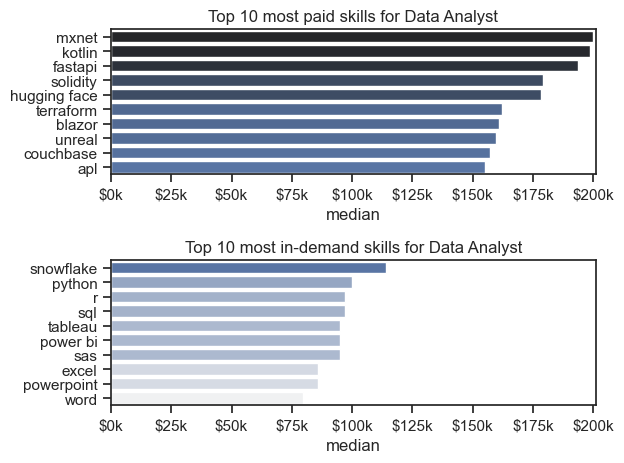

In [34]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style="ticks")

sns.barplot(data=df_top_pay, y="job_skills", x="median" , ax=ax[0], hue="median" , palette="dark:b_r")
ax[0].legend().remove()
ax[0].set_title("Top 10 most paid skills for Data Analyst")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
ax[0].set_xlim(0,201000)

sns.barplot(data=df_top_skills, y="job_skills", x="median" , ax=ax[1], hue="median" , palette="light:b")
ax[1].legend().remove()
ax[1].set_title("Top 10 most in-demand skills for Data Analyst")
ax[1].set_ylabel("")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
ax[1].set_xlim(0,201000)

fig.tight_layout()
